# gaussian mixture model

GMM on a subset of the data 

In [4]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.mixture import GaussianMixture
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [5]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150

warnings.simplefilter(action='ignore', category=FutureWarning)

### Setup

In [6]:
base_dir = Path("/home/workspace/projects/drg")
#base_dir = Path("/home/workspace/temp/madv2/")

input_dir = os.path.join(base_dir, 'h5ad/export_03/')

### Read and process adata

In [24]:
adata = sc.read_h5ad(os.path.join(input_dir, 'adata-scvi-leiden-annotated-no-transgenes.h5ad'))
adata

AnnData object with n_obs × n_vars = 95966 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1_nt'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate_mean'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_1_nt', 'leiden_sc

In [30]:
bdata = sc.read_h5ad(os.path.join(input_dir, 'adata-scvi-leiden.h5ad'))
bdata

AnnData object with n_obs × n_vars = 95966 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_1', 'leiden_scVI_1_colors', 'log1p', 'neighbors', 'output_id_colors', 'rank_genes_groups', 'umap'
    obsm: 'X_scVI', 'X_umap', 'spatial'
    layers: 'counts', 'log1p', 'normalized_1e6'
    obsp: 'connectivities', 'distances'

In [25]:
#genes = ['Cre_Seq5', 'EGFP_Seq1', 'Flp_Seq4', 'mCherry_Seq3', 'tdTomato_Seq2']

#genes = ['EGFP_Seq1', 'tdTomato_Seq2']

transgenes = ['Cre_Seq5', 'EGFP_Seq1', 'Flp_Seq4', 'mCherry_Seq3', 'tdTomato_Seq2']

# Remove transgenes from adata
#adata = adata[:, ~adata.var_names.isin(transgenes)].copy()

#print(f"adata shape after removing transgenes: {adata.shape}")

adata shape after removing transgenes: (95966, 475)


In [36]:
adata

AnnData object with n_obs × n_vars = 95966 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1_nt'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate_mean'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_1_nt', 'leiden_sc

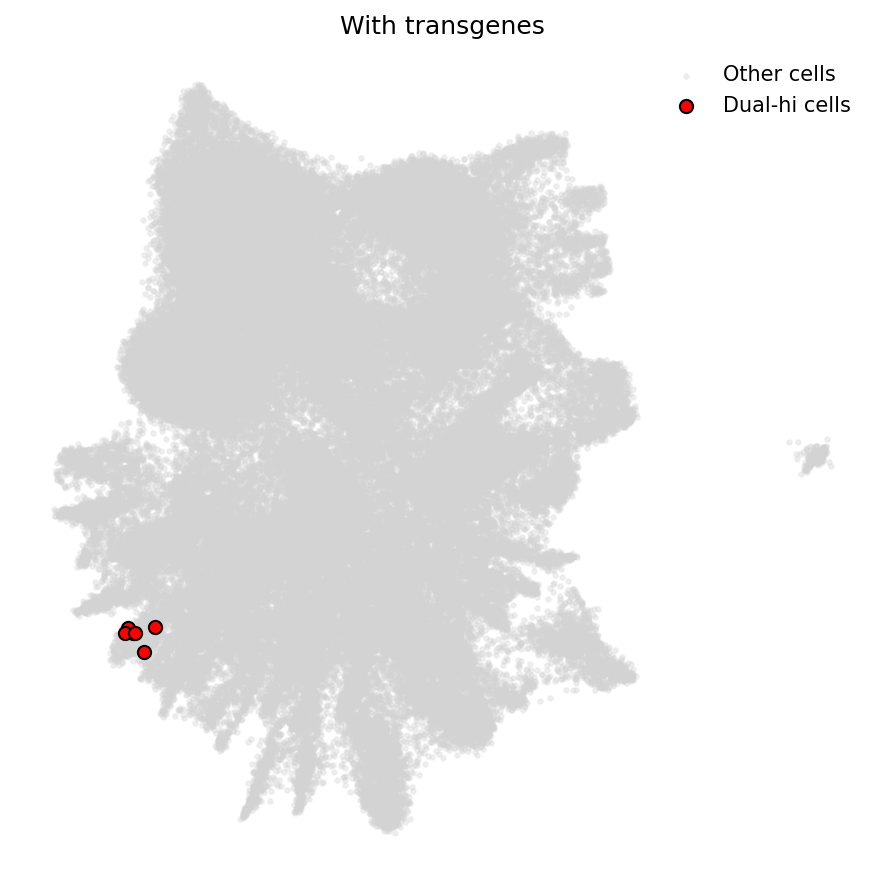

In [35]:

dual_hi_barcodes = ['bpoikicj-1-0', 'bmjgagok-1-1', 'ijnggkoc-1-1', 
                    'akcoadof-1-3', 'bgmdeeeb-1-3', 'hjjgalia-1-3']

umap = adata.obsm["X_umap"]
mask = adata.obs_names.isin(dual_hi_barcodes)

plt.figure(figsize=(6,6))

# Background (all other cells)
plt.scatter(
    umap[~mask, 0],
    umap[~mask, 1],
    s=5,
    c='lightgray',
    alpha=0.3,
    label='Other cells'
)

# Highlight your dual_hi cells
plt.scatter(
    umap[mask, 0],
    umap[mask, 1],
    s=40,
    c='red',
    edgecolors='black',
    linewidths=1,
    label='Dual-hi cells'
)

plt.axis('off')
plt.legend(frameon=False)
plt.title('With transgenes')
plt.tight_layout()
plt.show()

In [34]:
bdata

AnnData object with n_obs × n_vars = 95966 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_1', 'leiden_scVI_1_colors', 'log1p', 'neighbors', 'output_id_colors', 'rank_genes_groups', 'umap'
    obsm: 'X_scVI', 'X_umap', 'spatial'
    layers: 'counts', 'log1p', 'normalized_1e6'
    obsp: 'connectivities', 'distances'

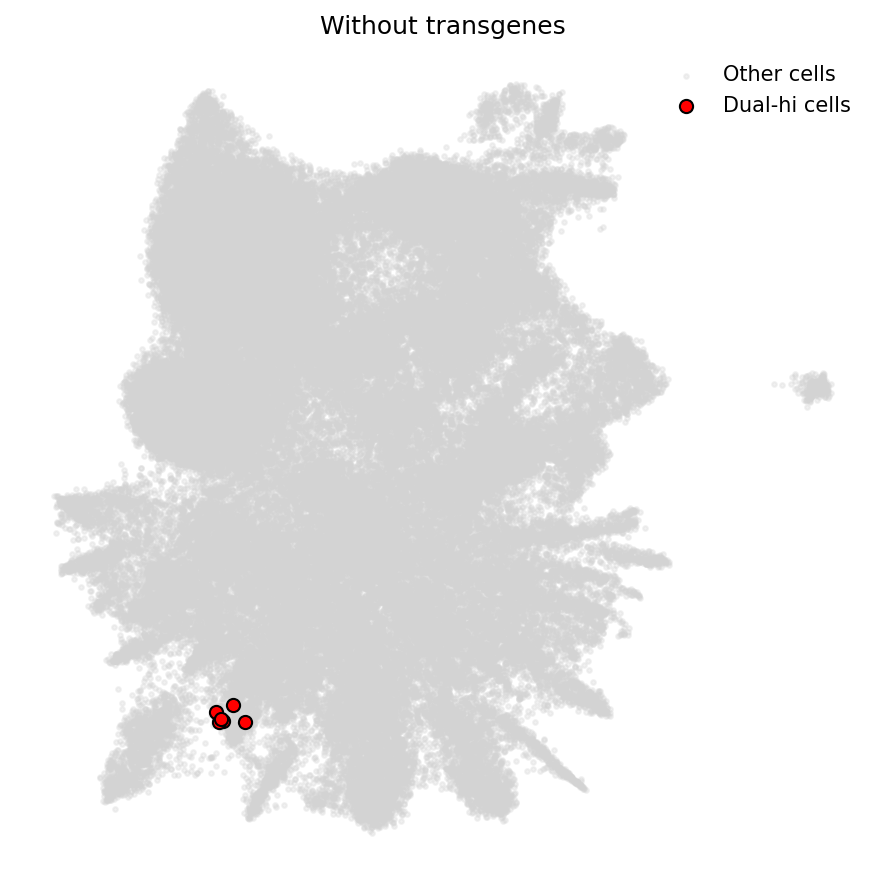

In [31]:

dual_hi_barcodes = ['bpoikicj-1-0', 'bmjgagok-1-1', 'ijnggkoc-1-1', 
                    'akcoadof-1-3', 'bgmdeeeb-1-3', 'hjjgalia-1-3']

umap = bdata.obsm["X_umap"]
mask = bdata.obs_names.isin(dual_hi_barcodes)

plt.figure(figsize=(6,6))

# Background (all other cells)
plt.scatter(
    umap[~mask, 0],
    umap[~mask, 1],
    s=5,
    c='lightgray',
    alpha=0.3,
    label='Other cells'
)

# Highlight your dual_hi cells
plt.scatter(
    umap[mask, 0],
    umap[mask, 1],
    s=40,
    c='red',
    edgecolors='black',
    linewidths=1,
    label='Dual-hi cells'
)

plt.axis('off')
plt.legend(frameon=False)
plt.title('Without transgenes')
plt.tight_layout()
plt.show()

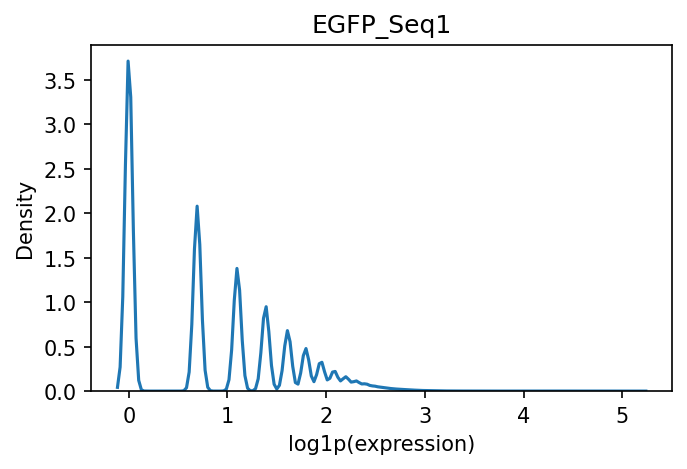

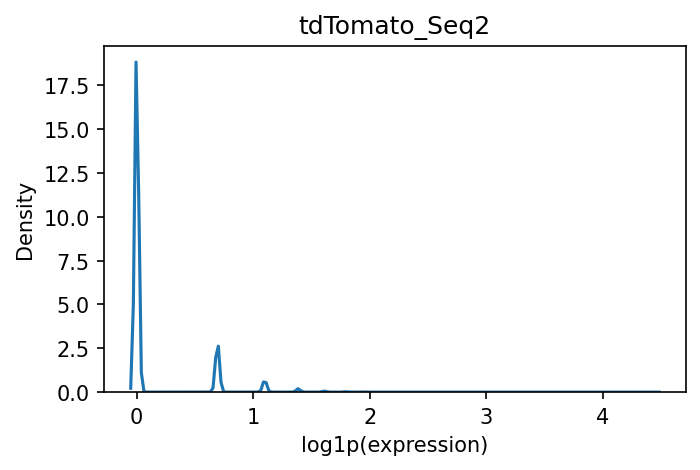

In [6]:
for g in genes:
    x = adata[:, g].X
    if hasattr(x, "toarray"): x = x.toarray().ravel()
    else: x = np.ravel(x)
    x = np.log1p(x)   # log-transform
    
    plt.figure(figsize=(5,3))
    sns.kdeplot(x, bw_adjust=0.5)
    plt.title(g)
    plt.xlabel("log1p(expression)")
    plt.ylabel("Density")
    plt.show()

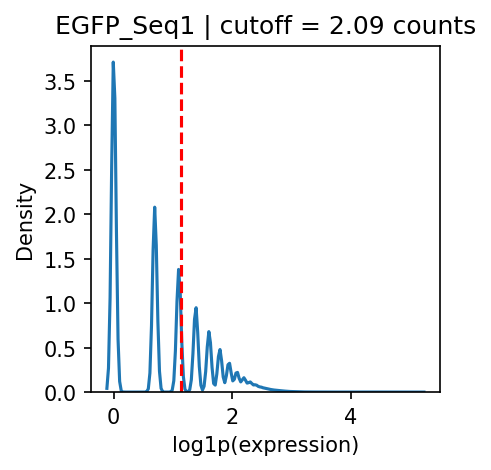

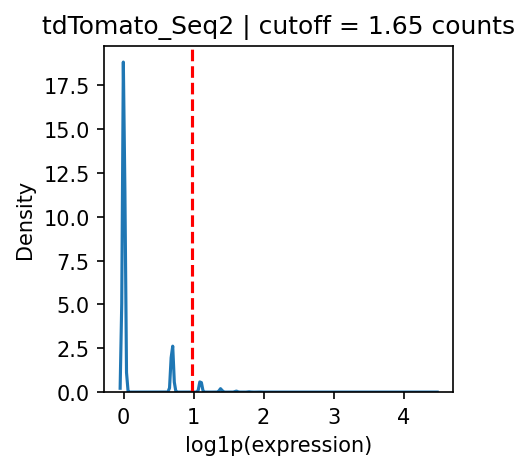

In [7]:
from sklearn.mixture import GaussianMixture
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

n_components = 3  # can test 2–4

for g in genes:
    x = adata[:, g].X
    if hasattr(x, "toarray"): x = x.toarray().ravel()
    else: x = np.ravel(x)
    x = np.log1p(x).reshape(-1,1)
    
    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x)
    means = np.sort(gmm.means_.flatten())

    # pick threshold between 1st and 2nd peaks for "positive"
    # or between 2nd and 3rd if you want "strong positive only"
    threshold_log = (means[1] + means[2]) / 2 if n_components >= 3 else np.mean(means)
    threshold = np.expm1(threshold_log)

    sns.kdeplot(x.ravel(), bw_adjust=0.5)
    plt.axvline(threshold_log, color="red", ls="--")
    plt.title(f"{g} | cutoff = {threshold:.2f} counts")
    plt.xlabel("log1p(expression)")
    plt.show()

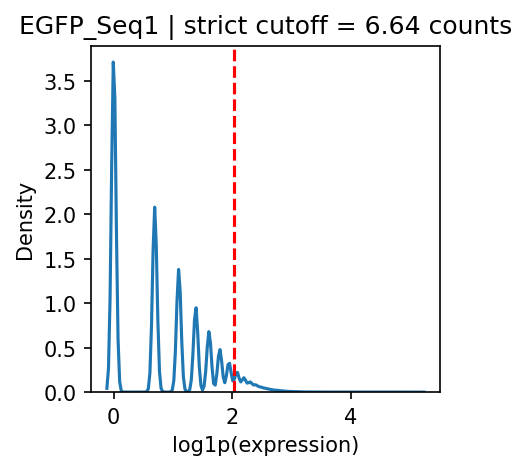

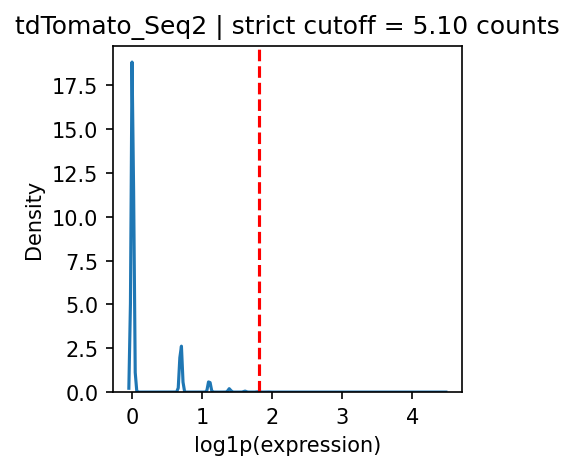

Applied strict thresholds:
EGFP_Seq1: cutoff=6.64, positives=4682/95966 (4.879%)
tdTomato_Seq2: cutoff=5.10, positives=156/95966 (0.163%)

Dual-positive counts:
EGFP_tdTomato_dual
False    95921
True        45
Name: count, dtype: int64


In [8]:
genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 4       # finer clustering
prob_threshold = 0.9   # increase for stricter selection (0.95–0.99 = very strict)

thresholds = {}

for g in genes:
    # get expression
    x = adata[:, g].X
    x = x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)
    x_log = np.log1p(x).reshape(-1, 1)

    # fit GMM and compute posterior probabilities
    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x_log)
    means = gmm.means_.flatten()
    probs = gmm.predict_proba(x_log)

    # identify cluster with highest mean (true positive cluster)
    high_cluster = np.argmax(means)

    # strict positive: high posterior in highest cluster AND expression > its mean
    pos_mask = (probs[:, high_cluster] > prob_threshold) & (x > np.expm1(means[high_cluster]))
    adata.obs[f"{g}_pos"] = pos_mask
    thresholds[g] = np.expm1(means[high_cluster])

    # optional visualization
    sns.kdeplot(x_log.ravel(), bw_adjust=0.5)
    plt.axvline(means[high_cluster], color='red', ls='--')
    plt.title(f"{g} | strict cutoff = {thresholds[g]:.2f} counts")
    plt.xlabel("log1p(expression)")
    plt.show()

# summary
print("Applied strict thresholds:")
for g, thr in thresholds.items():
    n_pos = adata.obs[f"{g}_pos"].sum()
    n_total = adata.n_obs
    print(f"{g}: cutoff={thr:.2f}, positives={n_pos}/{n_total} ({100*n_pos/n_total:.3f}%)")

# dual-positive label
adata.obs['EGFP_tdTomato_dual'] = adata.obs['EGFP_Seq1_pos'] & adata.obs['tdTomato_Seq2_pos']
print("\nDual-positive counts:")
print(adata.obs['EGFP_tdTomato_dual'].value_counts())

In [9]:
import numpy as np

genes = ['EGFP_Seq1', 'tdTomato_Seq2']
outlier_factor = 3.0  # higher = more conservative (3–5 typical)

for g in genes:
    x = adata[:, g].X
    x = x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)
    x_log = np.log1p(x)

    med = np.median(x_log)
    mad = np.median(np.abs(x_log - med))
    z = (x_log - med) / (mad * 1.4826)  # robust z-score

    adata.obs[f"{g}_outlier"] = z > outlier_factor

    print(f"{g}: {adata.obs[f'{g}_outlier'].sum()} outliers "
          f"({adata.obs[f'{g}_outlier'].mean()*100:.2f}%)")

EGFP_Seq1: 43 outliers (0.04%)
tdTomato_Seq2: 15950 outliers (16.62%)


/tmp/ipykernel_17000/2080264298.py:13: RuntimeWarning: divide by zero encountered in divide
  z = (x_log - med) / (mad * 1.4826)  # robust z-score
/tmp/ipykernel_17000/2080264298.py:13: RuntimeWarning: invalid value encountered in divide
  z = (x_log - med) / (mad * 1.4826)  # robust z-score


In [9]:
from sklearn.mixture import GaussianMixture
import numpy as np

genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 3
prob_threshold = 0.99     # confident in top cluster
within_cluster_q = 0.99   # top 1% of high cluster

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

for g in genes:
    x = to_dense(adata[:, g].X)
    x_log = np.log1p(x).reshape(-1, 1)

    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x_log)
    probs = gmm.predict_proba(x_log)
    means = gmm.means_.flatten()
    high_cluster = np.argmax(means)

    # cells confidently assigned to high cluster
    high_mask = probs[:, high_cluster] > prob_threshold
    x_high = x[high_mask]

    # define a within-cluster extreme cutoff (e.g. 99th percentile)
    thr_expr = np.percentile(x_high, within_cluster_q * 100)
    hi_mask = high_mask & (x > thr_expr)

    adata.obs[f"{g}_hi"] = hi_mask
    print(
        f"{g}: high_cluster_mean={np.expm1(means[high_cluster]):.2f}, "
        f"thr={thr_expr:.2f}, "
        f"n_hi={hi_mask.sum()} ({100*hi_mask.mean():.4f}%)"
    )

adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] & adata.obs['tdTomato_Seq2_hi']
)
n_dual = adata.obs['EGFP_tdTomato_dual_hi'].sum()
print(f"\nUltra-strict dual positives: {n_dual}/{adata.n_obs} "
      f"({100*n_dual/adata.n_obs:.4f}%)")

KeyError: 'EGFP_Seq1'

In [10]:
# ensure the column name matches exactly
cluster_col = "leiden_scVI_1_nt"
dual_col = "EGFP_tdTomato_dual_hi"

# tabulate counts of dual-positives per cluster
dual_by_cluster = (
    adata.obs.loc[adata.obs[dual_col], cluster_col]
    .value_counts()
    .sort_index()
)

# also normalize to cluster size
cluster_sizes = adata.obs[cluster_col].value_counts().sort_index()
frac_by_cluster = (dual_by_cluster / cluster_sizes).fillna(0)

# combine into one table for inspection
import pandas as pd
dual_summary = pd.DataFrame({
    "dual_pos_cells": dual_by_cluster,
    "cluster_size": cluster_sizes,
    "fraction_dual_pos": frac_by_cluster
}).fillna(0)

# sort by fraction descending
dual_summary = dual_summary.sort_values("fraction_dual_pos", ascending=False)

print(dual_summary)

KeyError: 'EGFP_tdTomato_dual_hi'

In [11]:
umap = adata.obsm["X_umap"]
mask = adata.obs["EGFP_tdTomato_dual_hi"].values

plt.figure(figsize=(6,6))

# Background (False) cells
plt.scatter(
    umap[~mask, 0],
    umap[~mask, 1],
    s=5,
    c='lightgray',
    alpha=0.3,
    label='Other cells'
)

plt.scatter(
    umap[mask, 0],
    umap[mask, 1],
    s=70,
    c='red',
    alpha=0.6,
    linewidths=0,
    label='Dual-positive'
)

plt.scatter(
    umap[mask, 0],
    umap[mask, 1],
    s=40,
    facecolors='none',   # no fill
    edgecolors='black',  # solid border
    linewidths=1.0,
    alpha=1.0,
    #label='Dual-positive border'
)

plt.axis('off')
plt.legend(frameon=False)
plt.title('tentative dual-positive neurons')
plt.show()

KeyError: 'EGFP_tdTomato_dual_hi'

In [15]:
print("adata shape:", adata.shape)
print("X_umap shape:", adata.obsm['X_umap'].shape)
print("obs names match:", all(adata.obs_names == adata.obs_names))

adata shape: (95966, 480)
X_umap shape: (95966, 2)
obs names match: True


In [18]:
[g for g in adata.var_names if "Cysltr2" in g]

['Cysltr2']

IndexError: index 191931 is out of bounds for axis 0 with size 95966

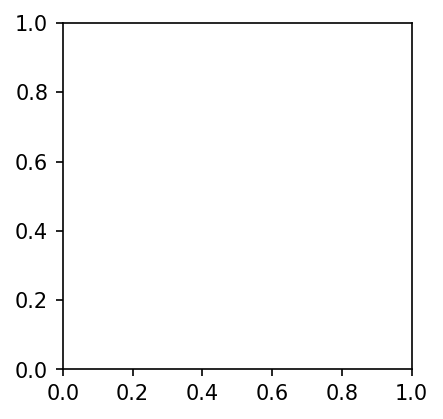

In [17]:
sc.pl.umap(adata, color = 'Cysltr2')

In [ ]:
sc.pl.umap(adata, color = 'leiden_scVI_1')

In [ ]:
adata_copy = adata.copy()

In [ ]:
sc.pl.umap(
    adata.copy(),
    color="leiden_scVI_1",
    groups=["9"],                 # highlight only cluster 9
    palette=["lightgray", "red"], 
    frameon=False,
    title="Cluster 9",
    show=True
)

In [ ]:
sc.pl.umap(adata, color = ['Cysltr2', 'Mrgprd', 'Scn10a', 'P2rx3', 'Ntrk1', 'Sst', 'Nppb', 'Il31ra', 'Osmr', 'Il4ra'])

In [ ]:
cluster_col = "leiden_scVI_1"

sc.tl.rank_genes_groups(
    adata,
    groupby=cluster_col,
    method="wilcoxon",
    use_raw=False
)

rankings = adata.uns["rank_genes_groups"]
groups = rankings["names"].dtype.names  # cluster labels

top3_genes = {}
for g in groups:
    genes = rankings["names"][g][:3].tolist()
    top3_genes[g] = genes

for cluster, genes in top3_genes.items():
    print(f"\nCluster {cluster} top genes: {genes}")
    sc.pl.umap(
        adata,
        color=genes,
        frameon=False,
        cmap="Reds",
        title=[f"Cluster {cluster} – {g}" for g in genes],
        ncols=3
    )